# Mix RIR → CQT (vivo / thinkpad / flow)

Apply room impulse responses to **cross-domain** chord audio in memory, then extract CQT.

- Does **not** touch training audio/features (model stays clean-trained).
- **Always** convolves (p=1); **random IR per sample** from the indoor bank (`rir-prep.ipynb`).
- Process fully in memory — **no wet wavs on disk**; only CQT npz + CSV manifest.
- Datasets: **vivo**, **thinkpad**, **flow** (ROG Flow / `evaluations/test-all`).
- Per-dataset **checkpoints** every N samples so a crash can resume.
- CQT params match chord extractors (48 kHz, hop 512, 6×36 bins, 188 frames, dB ref=max).

## Config

In [1]:
from os import path
import librosa
import pandas as pd
from IPython.display import display

# --- chord audio roots (non-training only) ---
CHORD_DATASETS = ["vivo", "thinkpad", "flow"]
DATASET_ROOTS = {
    "vivo": path.normpath("../../datasets/vivo"),
    "thinkpad": path.normpath("../../datasets/thinkpad"),
    "flow": path.normpath("../../evaluations/test-all"),
}
# Optional: clean feature packs (for label/file alignment when present)
FEATURES_DIR = path.normpath("../../features")
CLEAN_FEATURES = {
    "vivo": path.join(FEATURES_DIR, "vivo.npz"),
    "thinkpad": path.join(FEATURES_DIR, "thinkpad.npz"),
    "flow": path.join(FEATURES_DIR, "flow.npz"),
}

# --- RIR bank (from rir-prep.ipynb) ---
RIR_BANK = path.normpath("../../features/rir/ir-survey-indoor_no_bathroom.npz")
BANK_TAG = "indoor_no_bathroom"

# --- mix behaviour ---
RNG_SEED = 42
# always convolve; probability kept for symmetry with noise notebook (must be 1.0)
CONVOLVE_PROBABILITY = 1.0
assert CONVOLVE_PROBABILITY == 1.0, "This pipeline always convolves; set prep filter instead"

# --- outputs ---
OUT_NAME_TEMPLATE = "{dataset}-rir-{bank_tag}.npz"
MANIFEST_NAME_TEMPLATE = "{dataset}-rir-{bank_tag}.manifest.csv"
CKPT_NAME_TEMPLATE = "{dataset}-rir-{bank_tag}.ckpt.npz"
FORCE_REMIX = False
CHECKPOINT_EVERY = 50

# Stable per-dataset seeds
DATASET_SEED_OFFSET = {"vivo": 11, "thinkpad": 22, "flow": 33}

# --- CQT params (must match chord extraction) ---
AUDIO_MIN_DURATION = 2  # seconds → frame budget
AUDIO_SAMPLE_RATE = 48_000
CQT_HOP_LENGTH = 512
CQT_OCTAVES = 6
CQT_BINS_PER_OCTAVE = 36
CQT_FEATURE_FRAMES = round(AUDIO_MIN_DURATION * AUDIO_SAMPLE_RATE / CQT_HOP_LENGTH)
CQT_FMIN = librosa.note_to_hz("C1")

config_df = pd.DataFrame(
    [
        {"key": "chord_datasets", "value": CHORD_DATASETS},
        {"key": "rir_bank", "value": RIR_BANK},
        {"key": "bank_tag", "value": BANK_TAG},
        {"key": "rng_seed", "value": RNG_SEED},
        {"key": "convolve_probability", "value": CONVOLVE_PROBABILITY},
        {"key": "force_remix", "value": FORCE_REMIX},
        {"key": "checkpoint_every", "value": CHECKPOINT_EVERY},
        {"key": "feature_bins", "value": CQT_BINS_PER_OCTAVE * CQT_OCTAVES},
        {"key": "feature_frames", "value": CQT_FEATURE_FRAMES},
        {"key": "out_template", "value": OUT_NAME_TEMPLATE},
    ]
).set_index("key")
display(config_df)

,value
key,
chord_datasets,"[vivo, thinkpad, flow]"
rir_bank,../../features/rir/ir-survey-indoor_no_bathroo...
bank_tag,indoor_no_bathroom
rng_seed,42
convolve_probability,1.0
force_remix,False
checkpoint_every,50
feature_bins,216
feature_frames,188


## Helpers

In [2]:
import csv
import re
from collections import OrderedDict
from os import makedirs, remove
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
from scipy.signal import fftconvolve
from IPython.display import display
from tqdm.notebook import tqdm
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

AUDIO_EXTS = {".wav", ".ogg", ".flac", ".mp3"}


def natural_key(s: str):
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r"(\d+)", s)]


def load_rir_bank(bank_path: str) -> dict:
    data = np.load(bank_path, allow_pickle=True)
    irs = data["irs"]
    names = data["names"].astype(str)
    rooms = data["rooms"].astype(str)
    target_sr = int(data["target_sr"]) if "target_sr" in data.files else AUDIO_SAMPLE_RATE
    assert target_sr == AUDIO_SAMPLE_RATE, f"RIR bank sr={target_sr} != {AUDIO_SAMPLE_RATE}"
    assert len(irs) > 0
    meta_df = pd.DataFrame(
        [{
            "bank_path": bank_path,
            "n_irs": len(names),
            "n_rooms": int(len(np.unique(rooms))),
            "target_sr": target_sr,
            "bank_tag": str(data["bank_tag"]) if "bank_tag" in data.files else "",
            "duration_s_median": float(np.median(data["durations_s"])) if "durations_s" in data.files else None,
        }]
    )
    room_counts = (
        pd.Series(rooms).value_counts().rename_axis("room").reset_index(name="n")
    )
    display(meta_df)
    display(room_counts.head(20))
    return {
        "irs": irs,
        "names": names,
        "rooms": rooms,
        "n": len(names),
        "bank_tag": str(data["bank_tag"]) if "bank_tag" in data.files else BANK_TAG,
    }


def resolve_audio_list(dataset: str) -> pd.DataFrame:
    """Return DataFrame with columns: relpath, path, label (order matches clean npz when possible)."""
    root = Path(DATASET_ROOTS[dataset])
    assert root.is_dir(), f"Missing dataset root: {root}"
    clean_path = CLEAN_FEATURES.get(dataset)

    if clean_path and path.isfile(clean_path):
        clean = np.load(clean_path, allow_pickle=True)
        labels = np.asarray(clean["labels"]).astype(str)
        if "files" in clean.files:
            rels = np.asarray(clean["files"]).astype(str)
            rows = []
            for rel, lab in zip(rels, labels):
                p = root / rel
                # flow may store .wav names but on-disk is .ogg — try swap
                if not p.is_file():
                    alt = p.with_suffix(".ogg" if p.suffix.lower() == ".wav" else ".wav")
                    if alt.is_file():
                        p = alt
                        rel = str(Path(rel).with_suffix(p.suffix))
                if not p.is_file():
                    raise FileNotFoundError(f"{dataset}: missing audio {root / rel}")
                rows.append({"relpath": rel, "path": str(p), "label": lab})
            return pd.DataFrame(rows)

        # no files key (flow): rebuild by first-appearance class order + natural sort
        class_order = list(OrderedDict.fromkeys(labels))
        rows = []
        for cls in class_order:
            folder = root / cls
            assert folder.is_dir(), f"Missing class folder: {folder}"
            paths = sorted(
                [p for p in folder.iterdir() if p.suffix.lower() in AUDIO_EXTS],
                key=lambda p: natural_key(p.name),
            )
            n_expect = int((labels == cls).sum())
            if len(paths) != n_expect:
                raise ValueError(
                    f"{dataset}/{cls}: found {len(paths)} audio, expected {n_expect}"
                )
            for p in paths:
                rows.append({
                    "relpath": str(p.relative_to(root)),
                    "path": str(p),
                    "label": cls,
                })
        df = pd.DataFrame(rows)
        assert len(df) == len(labels)
        assert list(df["label"]) == list(labels)
        return df

    # fallback: full tree natural sort by path
    paths = sorted(
        [p for p in root.rglob("*") if p.suffix.lower() in AUDIO_EXTS],
        key=lambda p: (p.parent.name, natural_key(p.name)),
    )
    rows = [
        {
            "relpath": str(p.relative_to(root)),
            "path": str(p),
            "label": p.parent.name,
        }
        for p in paths
    ]
    return pd.DataFrame(rows)


def preprocess_cqt(cqt: np.ndarray) -> np.ndarray:
    if cqt.shape[1] < CQT_FEATURE_FRAMES:
        pad_width = CQT_FEATURE_FRAMES - cqt.shape[1]
        cqt = np.pad(cqt, pad_width=((0, 0), (0, pad_width)), mode="constant")
    else:
        cqt = cqt[:, :CQT_FEATURE_FRAMES]
    return cqt


def convolve_crop(y: np.ndarray, h: np.ndarray) -> np.ndarray:
    """y * h, keep original length (leading IR already trimmed)."""
    wet = fftconvolve(y, h, mode="full")
    wet = wet[: len(y)]
    # numerical safety — amplitude_to_db(ref=max) is scale-invariant, but avoid zeros
    peak = float(np.max(np.abs(wet)))
    if peak > 0:
        wet = wet / peak
    return wet.astype(np.float32)


def extract_cqt_from_audio(y: np.ndarray, sr: int) -> np.ndarray:
    cqt = librosa.cqt(
        y=y,
        sr=sr,
        fmin=CQT_FMIN,
        n_bins=CQT_BINS_PER_OCTAVE * CQT_OCTAVES,
        bins_per_octave=CQT_BINS_PER_OCTAVE,
        hop_length=CQT_HOP_LENGTH,
        window="hann",
    )
    cqt = np.abs(cqt)
    cqt = librosa.amplitude_to_db(cqt, ref=np.max)
    return preprocess_cqt(cqt).astype(np.float32)


def process_one(audio_path: str, h: np.ndarray) -> np.ndarray:
    y, sr = librosa.load(audio_path, sr=AUDIO_SAMPLE_RATE, mono=True)
    y = y.astype(np.float32)
    wet = convolve_crop(y, h)
    return extract_cqt_from_audio(wet, sr)


def save_dataset_checkpoint(ckpt_path, features, labels, files, manifest_rows, next_index, errors):
    np.savez_compressed(
        ckpt_path,
        features=np.asarray(features, dtype=np.float32),
        labels=np.asarray(labels),
        files=np.asarray(files),
        manifest_json=np.asarray(manifest_rows, dtype=object),
        next_index=np.asarray(int(next_index)),
        n_features=np.asarray(len(features)),
        errors_json=np.asarray(errors, dtype=object),
    )


def process_dataset(dataset: str, rir_bank: dict, rng: np.random.Generator) -> dict:
    inventory = resolve_audio_list(dataset)
    n = len(inventory)
    out_path = path.join(
        FEATURES_DIR,
        OUT_NAME_TEMPLATE.format(dataset=dataset, bank_tag=BANK_TAG),
    )
    manifest_path = path.join(
        FEATURES_DIR,
        MANIFEST_NAME_TEMPLATE.format(dataset=dataset, bank_tag=BANK_TAG),
    )
    ckpt_path = path.join(
        FEATURES_DIR,
        CKPT_NAME_TEMPLATE.format(dataset=dataset, bank_tag=BANK_TAG),
    )

    if path.isfile(out_path) and not FORCE_REMIX:
        data = np.load(out_path, allow_pickle=True)
        return {
            "dataset": dataset,
            "status": "skipped_exists",
            "n_in": n,
            "n_out": int(data["features"].shape[0]),
            "shape": data["features"].shape,
            "out_path": out_path,
            "manifest_path": manifest_path if path.isfile(manifest_path) else None,
        }

    features = []
    labels = []
    files = []
    manifest_rows = []
    errors = []
    start_i = 0

    if path.isfile(ckpt_path) and not FORCE_REMIX:
        ckpt = np.load(ckpt_path, allow_pickle=True)
        features = list(ckpt["features"])
        labels = list(ckpt["labels"].astype(str))
        files = list(ckpt["files"].astype(str))
        manifest_rows = list(ckpt["manifest_json"])
        if "errors_json" in ckpt.files:
            errors = list(ckpt["errors_json"])
        # next chord index to process (RNG draws == one per chord index attempted)
        start_i = int(ckpt["next_index"]) if "next_index" in ckpt.files else len(features)
        display(pd.DataFrame([{
            "dataset": dataset,
            "status": "resumed_checkpoint",
            "next_index": start_i,
            "n_features": len(features),
            "ckpt": ckpt_path,
        }]))
    elif FORCE_REMIX and path.isfile(ckpt_path):
        remove(ckpt_path)

    # Replay RNG draws for already-attempted chord indices
    if start_i > 0:
        _ = rng.integers(0, rir_bank["n"], size=start_i)

    for i in tqdm(range(start_i, n), desc=f"RIR-CQT {dataset}", initial=start_i, total=n):
        row = inventory.iloc[i]
        rir_i = int(rng.integers(0, rir_bank["n"]))
        h = rir_bank["irs"][rir_i]
        try:
            cqt = process_one(row["path"], h)
            features.append(cqt)
            labels.append(row["label"])
            files.append(row["relpath"])
            manifest_rows.append({
                "out_index": len(features) - 1,
                "chord_index": i,
                "chord_file": row["relpath"],
                "chord_label": row["label"],
                "convolved": 1,
                "rir_index": rir_i,
                "rir_file": rir_bank["names"][rir_i],
                "rir_room": rir_bank["rooms"][rir_i],
            })
        except Exception as exc:
            errors.append({"index": i, "path": row["path"], "error": str(exc)})

        if (i + 1) % CHECKPOINT_EVERY == 0:
            save_dataset_checkpoint(
                ckpt_path, features, labels, files, manifest_rows,
                next_index=i + 1, errors=errors,
            )

    if not features:
        raise RuntimeError(f"{dataset}: no features extracted ({len(errors)} errors)")

    payload = {
        "features": np.asarray(features, dtype=np.float32),
        "labels": np.asarray(labels).astype(str),
        "files": np.asarray(files).astype(str),
        "source_dataset": np.asarray(dataset),
        "source_audio_root": np.asarray(DATASET_ROOTS[dataset]),
        "source_rir_bank": np.asarray(RIR_BANK),
        "rir_bank_tag": np.asarray(rir_bank["bank_tag"]),
        "rng_seed": np.asarray(RNG_SEED),
        "dataset_seed_offset": np.asarray(DATASET_SEED_OFFSET.get(dataset, -1)),
        "convolve_probability": np.asarray(CONVOLVE_PROBABILITY),
        "audio_sample_rate": np.asarray(AUDIO_SAMPLE_RATE),
        "cqt_hop_length": np.asarray(CQT_HOP_LENGTH),
        "cqt_bins": np.asarray(CQT_BINS_PER_OCTAVE * CQT_OCTAVES),
        "cqt_frames": np.asarray(CQT_FEATURE_FRAMES),
    }
    np.savez_compressed(out_path, **payload)

    with open(manifest_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=list(manifest_rows[0].keys()))
        writer.writeheader()
        writer.writerows(manifest_rows)

    if path.isfile(ckpt_path):
        remove(ckpt_path)

    if errors:
        display(pd.DataFrame(errors))

    return {
        "dataset": dataset,
        "status": "mixed",
        "n_in": n,
        "n_out": int(payload["features"].shape[0]),
        "n_errors": len(errors),
        "shape": payload["features"].shape,
        "out_path": out_path,
        "manifest_path": manifest_path,
    }


display(pd.DataFrame([{"helpers": "ready"}]))


,helpers
0,ready


## Run convolve + CQT

In [3]:
import pandas as pd
from IPython.display import display

assert path.isfile(RIR_BANK), f"Missing RIR bank: {RIR_BANK} (run rir-prep.ipynb)"
for name in CHORD_DATASETS:
    assert name != "training", "Do not apply RIR into training features"
    assert path.isdir(DATASET_ROOTS[name]), f"Missing audio root: {DATASET_ROOTS[name]}"

rir_bank = load_rir_bank(RIR_BANK)

# inventory preview
inv_rows = []
for name in CHORD_DATASETS:
    inv = resolve_audio_list(name)
    inv_rows.append({
        "dataset": name,
        "n": len(inv),
        "n_labels": int(inv["label"].nunique()),
        "example": inv.iloc[0]["relpath"],
        "audio_root": DATASET_ROOTS[name],
    })
display(pd.DataFrame(inv_rows))

results = []
for name in CHORD_DATASETS:
    offset = DATASET_SEED_OFFSET.get(name, 100 + CHORD_DATASETS.index(name))
    ds_rng = np.random.default_rng(RNG_SEED + offset)
    info = process_dataset(name, rir_bank, ds_rng)
    results.append(info)
    display(pd.DataFrame([info]))

results_df = pd.DataFrame(results)
display(results_df)

,bank_path,n_irs,n_rooms,target_sr,bank_tag,duration_s_median
0,../../features/rir/ir-survey-indoor_no_bathroo...,174,51,48000,indoor_no_bathroom,0.615292


,room,n
0,Classroom,35
1,Hallway,17
2,MITCampus,16
3,Bar,14
4,Office,11
5,Bedroom,10
6,Kitchen,5
7,Livingroom,4
8,Restaurant,4
9,Supermarket,4


,dataset,n,n_labels,example,audio_root
0,vivo,1440,36,A#_diminished_4/A#_diminished_4-1.wav,../../datasets/vivo
1,thinkpad,1440,36,A#_diminished_4/A#_diminished_4-1.wav,../../datasets/thinkpad
2,flow,1440,36,A#_diminished_4/A#_diminished_4-1.ogg,../../evaluations/test-all


,dataset,status,n_in,n_out,shape,out_path,manifest_path
0,vivo,skipped_exists,1440,1440,"(1440, 216, 188)",../../features/vivo-rir-indoor_no_bathroom.npz,../../features/vivo-rir-indoor_no_bathroom.man...


,dataset,status,n_in,n_out,shape,out_path,manifest_path
0,thinkpad,skipped_exists,1440,1440,"(1440, 216, 188)",../../features/thinkpad-rir-indoor_no_bathroom...,../../features/thinkpad-rir-indoor_no_bathroom...


,dataset,status,n_in,n_out,shape,out_path,manifest_path
0,flow,skipped_exists,1440,1440,"(1440, 216, 188)",../../features/flow-rir-indoor_no_bathroom.npz,../../features/flow-rir-indoor_no_bathroom.man...


,dataset,status,n_in,n_out,shape,out_path,manifest_path
0,vivo,skipped_exists,1440,1440,"(1440, 216, 188)",../../features/vivo-rir-indoor_no_bathroom.npz,../../features/vivo-rir-indoor_no_bathroom.man...
1,thinkpad,skipped_exists,1440,1440,"(1440, 216, 188)",../../features/thinkpad-rir-indoor_no_bathroom...,../../features/thinkpad-rir-indoor_no_bathroom...
2,flow,skipped_exists,1440,1440,"(1440, 216, 188)",../../features/flow-rir-indoor_no_bathroom.npz,../../features/flow-rir-indoor_no_bathroom.man...


## Verify

In [4]:
import numpy as np
import pandas as pd
from IPython.display import display

rows = []
for name in CHORD_DATASETS:
    out_path = path.join(
        FEATURES_DIR,
        OUT_NAME_TEMPLATE.format(dataset=name, bank_tag=BANK_TAG),
    )
    man_path = path.join(
        FEATURES_DIR,
        MANIFEST_NAME_TEMPLATE.format(dataset=name, bank_tag=BANK_TAG),
    )
    data = np.load(out_path, allow_pickle=True)
    x = data["features"]
    y = data["labels"].astype(str)
    man = pd.read_csv(man_path) if path.isfile(man_path) else None

    clean_path = CLEAN_FEATURES[name]
    clean_n = None
    clean_shape = None
    if path.isfile(clean_path):
        clean = np.load(clean_path, allow_pickle=True)
        clean_n = int(clean["features"].shape[0])
        clean_shape = clean["features"].shape

    rows.append({
        "dataset": name,
        "n": int(x.shape[0]),
        "shape": x.shape,
        "dtype": str(x.dtype),
        "n_classes": int(len(np.unique(y))),
        "finite": bool(np.isfinite(x).all()),
        "clean_n": clean_n,
        "clean_shape": clean_shape,
        "n_match_clean": clean_n == int(x.shape[0]) if clean_n is not None else None,
        "manifest_rows": len(man) if man is not None else None,
        "n_unique_rirs": int(man["rir_file"].nunique()) if man is not None else None,
        "all_convolved": bool((man["convolved"] == 1).all()) if man is not None else None,
    })

display(pd.DataFrame(rows))

,dataset,n,shape,dtype,n_classes,finite,clean_n,clean_shape,n_match_clean,manifest_rows,n_unique_rirs,all_convolved
0,vivo,1440,"(1440, 216, 188)",float32,36,True,1440,"(1440, 216, 188)",True,1440,174,True
1,thinkpad,1440,"(1440, 216, 188)",float32,36,True,1440,"(1440, 216, 188)",True,1440,174,True
2,flow,1440,"(1440, 216, 188)",float32,36,True,1440,"(1440, 216, 188)",True,1440,174,True


## Inspect clean vs RIR CQT

Side-by-side **clean | rir | rir − clean** for every pack in `CHORD_DATASETS` (same layout as noise mix inspect).

,dataset,n,mae_db_mean,mae_db_std,mae_db_p50,mae_db_p90,cos_sim_mean,cos_sim_p10,cos_sim_min
0,vivo,1440,4.796045,1.551199,4.839268,6.687845,0.995526,0.992318,0.987253


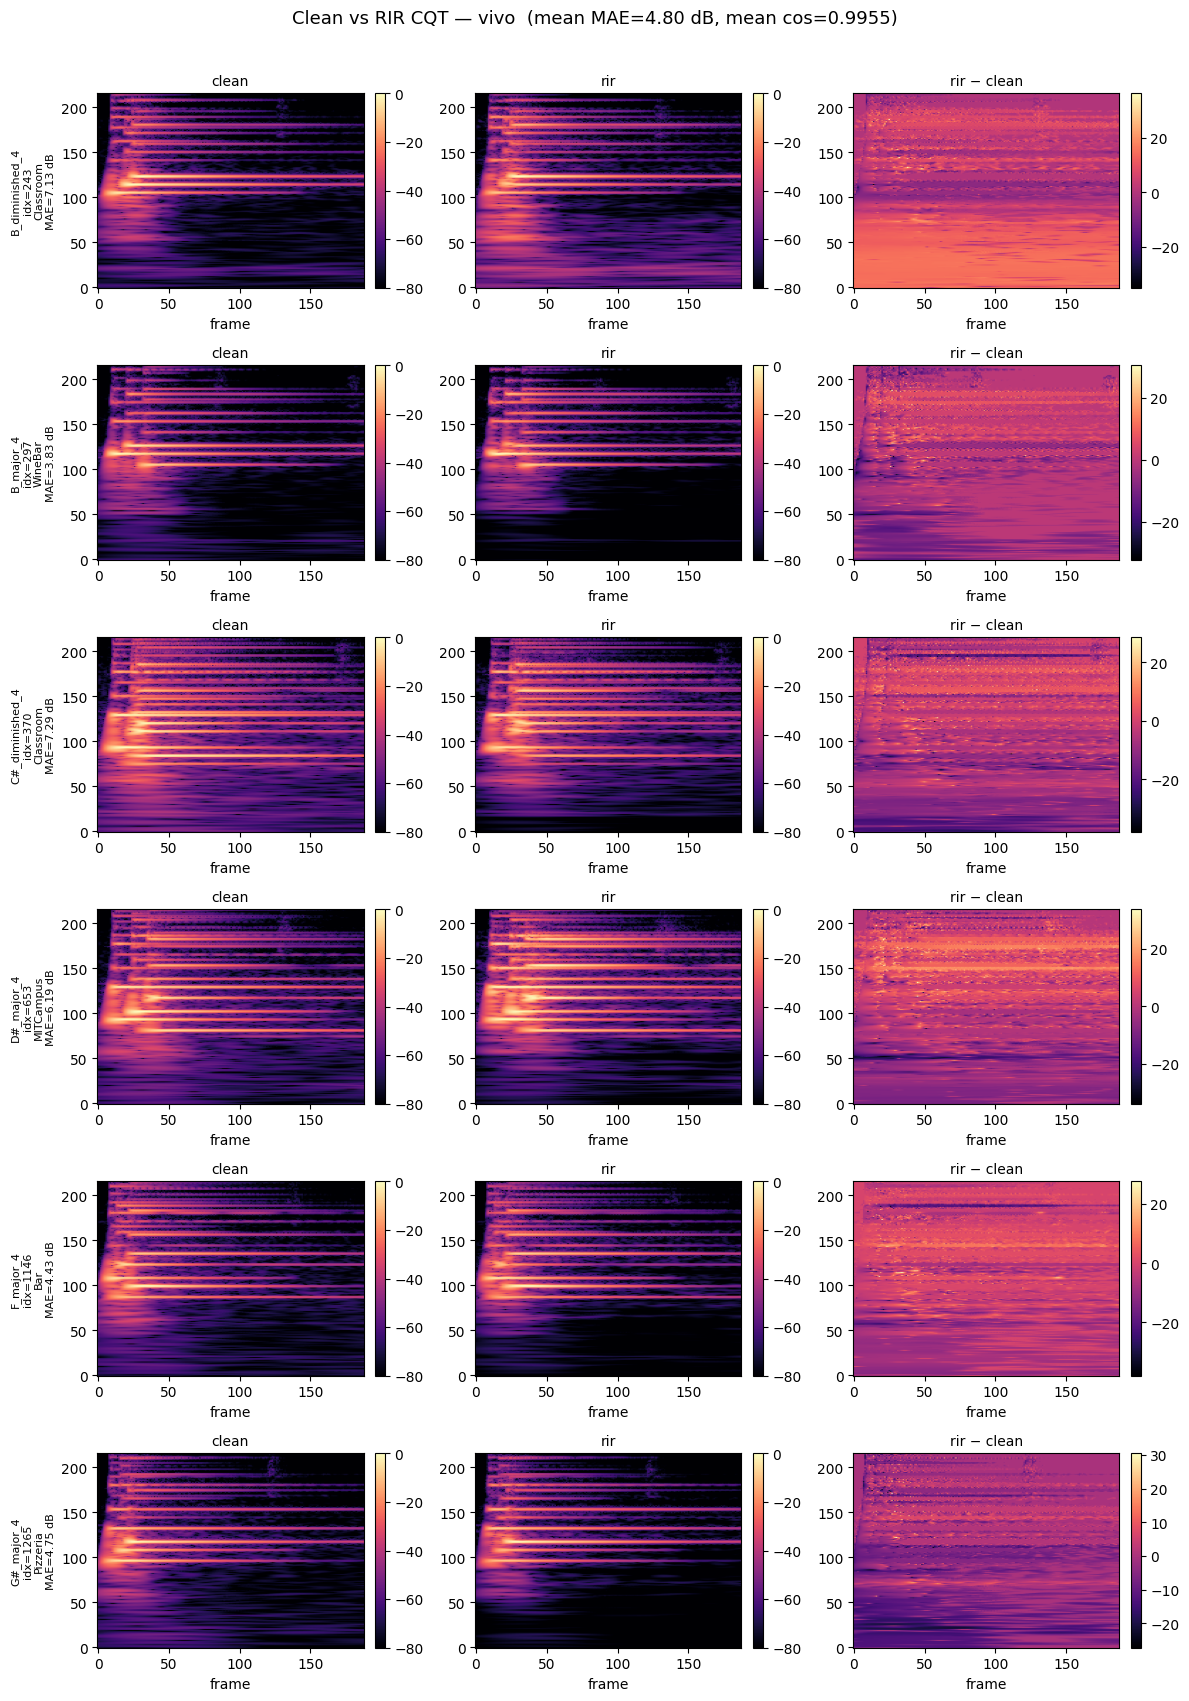

,dataset,out_index,chord_index,chord_label,chord_file,rir_room,rir_file,rir_index,convolved,mae_db,cos_sim
0,vivo,243,243,B_diminished_4,B_diminished_4/B_diminished_4-12.wav,Classroom,h258_Classroom_1txts.wav,162,1,7.126758,0.993734
1,vivo,297,297,B_major_4,B_major_4/B_major_4-25.wav,WineBar,h123_WineBar_1txts.wav,93,1,3.833165,0.997044
2,vivo,370,370,C#_diminished_4,C#_diminished_4/C#_diminished_4-19.wav,Classroom,h249_Classroom_1txts.wav,153,1,7.286965,0.992205
3,vivo,653,653,D#_major_4,D#_major_4/D#_major_4-21.wav,MITCampus,h201_MITCampus_DramaRoom_1txts.wav,131,1,6.187654,0.991279
4,vivo,1146,1146,F_major_4,F_major_4/F_major_4-33.wav,Bar,h035_Bar_LargeSportsBar_5txts.wav,30,1,4.427951,0.996711
5,vivo,1265,1265,G#_major_4,G#_major_4/G#_major_4-32.wav,Pizzeria,h214_Pizzeria_1txts.wav,134,1,4.749635,0.996532


,dataset,n,mae_db_mean,mae_db_std,mae_db_p50,mae_db_p90,cos_sim_mean,cos_sim_p10,cos_sim_min
0,thinkpad,1440,5.550022,1.745589,5.53525,7.770789,0.993044,0.988551,0.971448


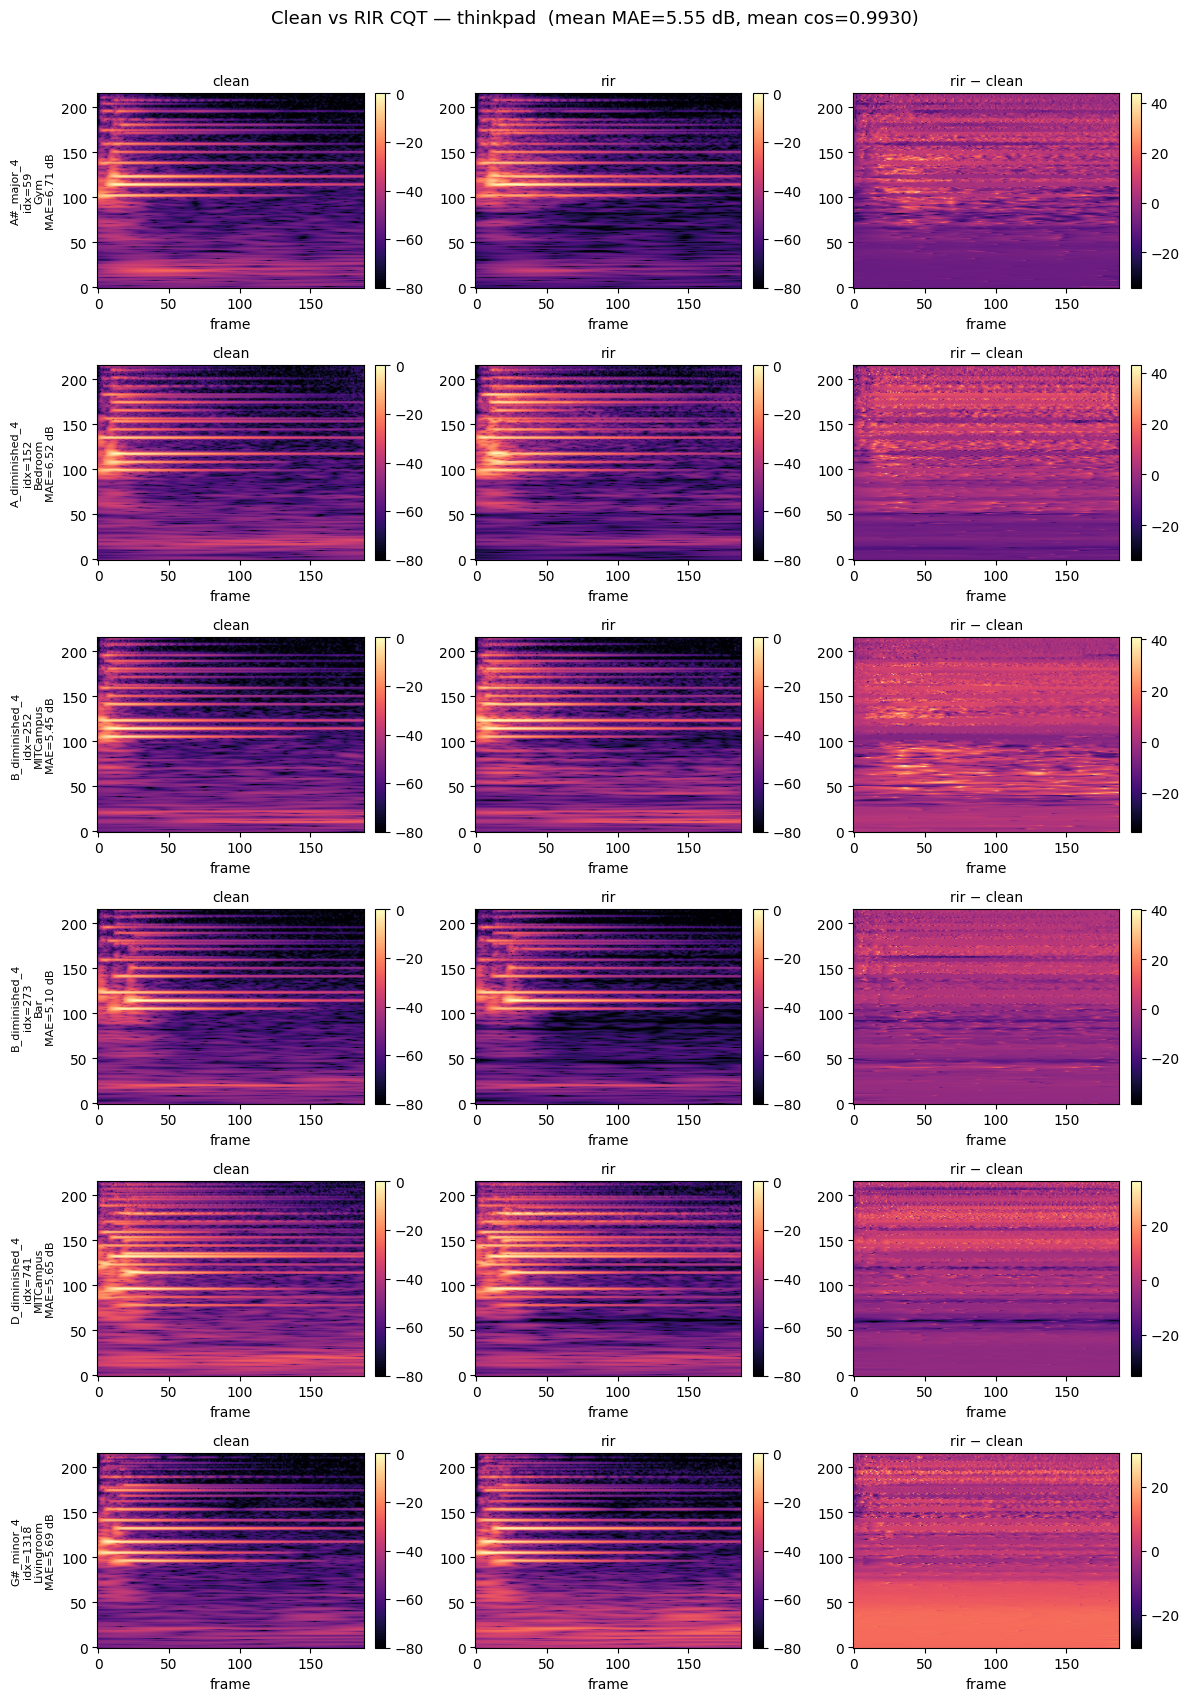

,dataset,out_index,chord_index,chord_label,chord_file,rir_room,rir_file,rir_index,convolved,mae_db,cos_sim
0,thinkpad,59,59,A#_major_4,A#_major_4/A#_major_4-27.wav,Gym,h052_Gym_WeightRoom_3txts.wav,41,1,6.713570,0.991245
1,thinkpad,152,152,A_diminished_4,A_diminished_4/A_diminished_4-39.wav,Bedroom,h031_Bedroom_7txts.wav,26,1,6.524045,0.989900
2,thinkpad,252,252,B_diminished_4,B_diminished_4/B_diminished_4-20.wav,MITCampus,h255_MITCampus_StudentLounge_1txts.wav,159,1,5.449155,0.992854
3,thinkpad,273,273,B_diminished_4,B_diminished_4/B_diminished_4-4.wav,Bar,h079_Bar_2txts.wav,57,1,5.096549,0.995947
4,thinkpad,741,741,D_diminished_4,D_diminished_4/D_diminished_4-29.wav,MITCampus,h177_MITCampus_LaundryRoom_1txts.wav,117,1,5.654932,0.991943
5,thinkpad,1318,1318,G#_minor_4,G#_minor_4/G#_minor_4-8.wav,Livingroom,h010_Livingroom_31txts.wav,8,1,5.690512,0.993640


,dataset,n,mae_db_mean,mae_db_std,mae_db_p50,mae_db_p90,cos_sim_mean,cos_sim_p10,cos_sim_min
0,flow,1440,6.703326,2.041648,6.808854,9.168218,0.983689,0.971795,0.946561


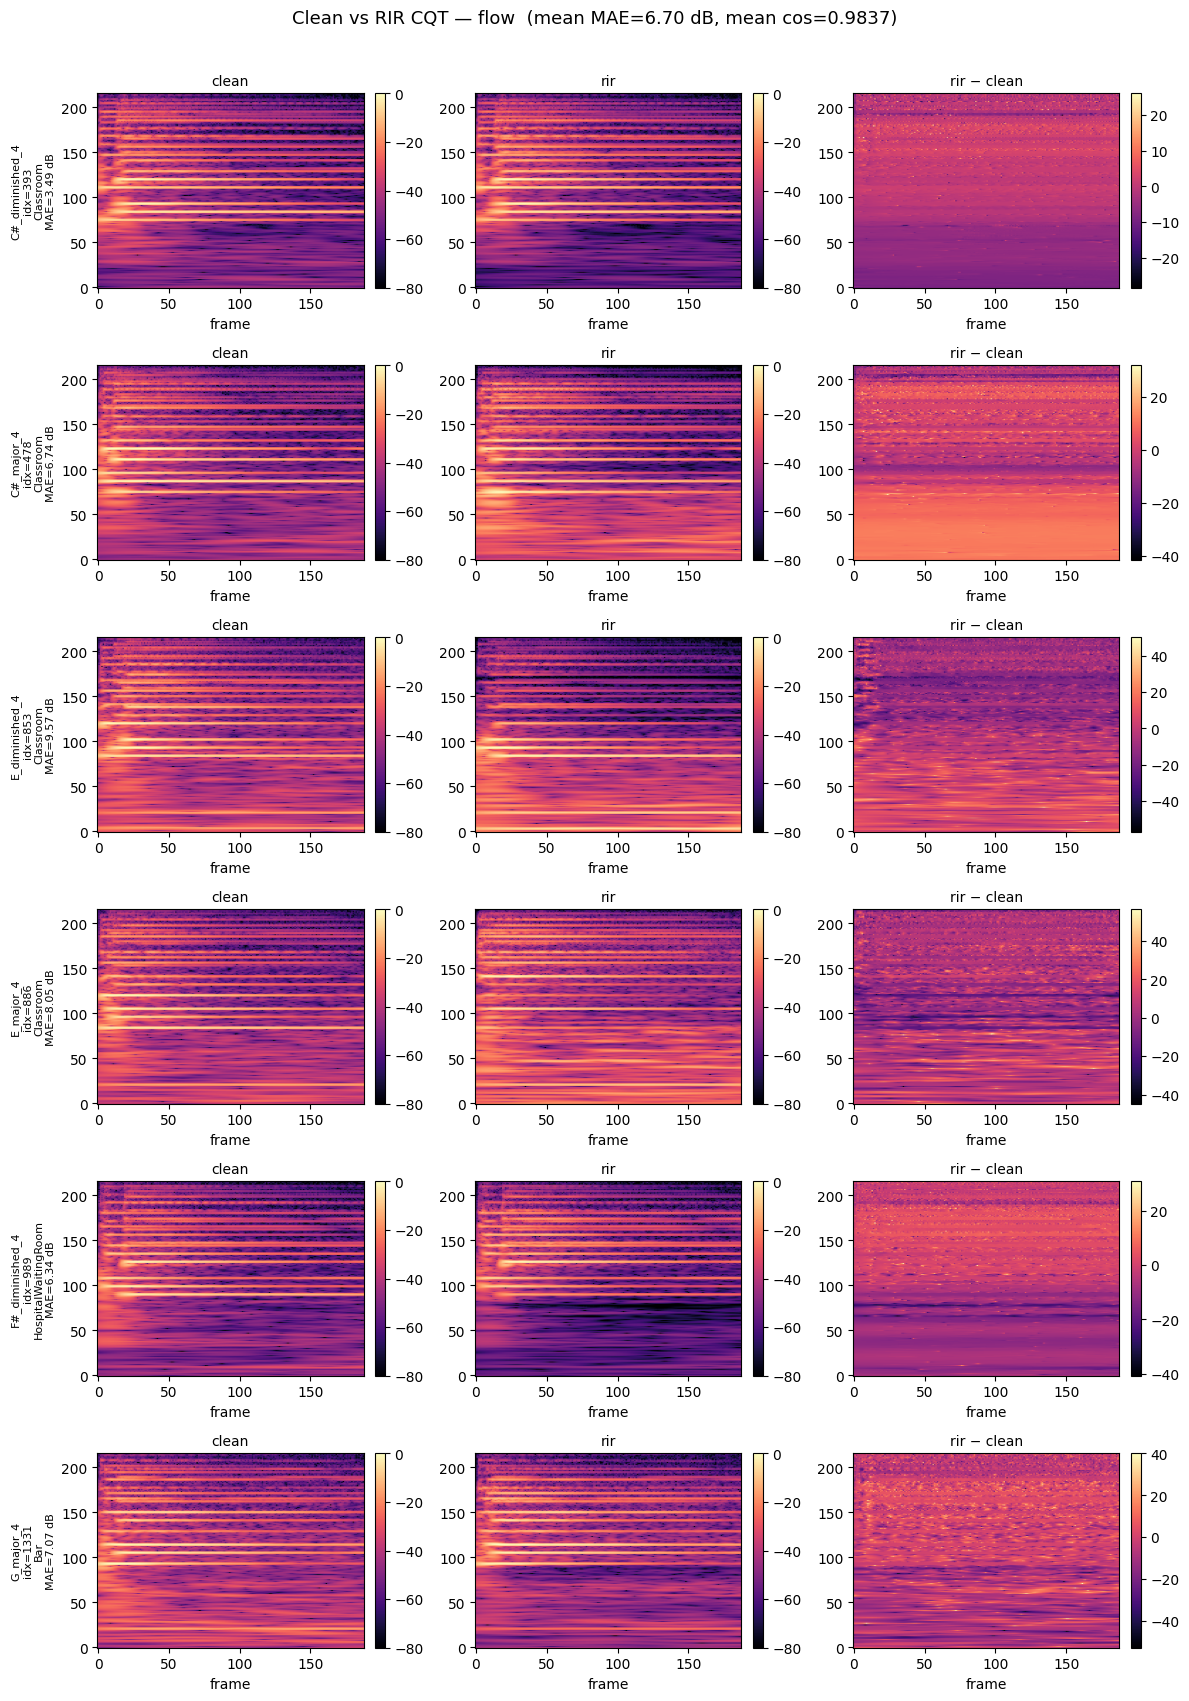

,dataset,out_index,chord_index,chord_label,chord_file,rir_room,rir_file,rir_index,convolved,mae_db,cos_sim
0,flow,393,393,C#_diminished_4,C#_diminished_4/C#_diminished_4-34.ogg,Classroom,h247_Classroom_1txts.wav,151,1,3.493859,0.996655
1,flow,478,478,C#_major_4,C#_major_4/C#_major_4-39.ogg,Classroom,h258_Classroom_1txts.wav,162,1,6.740351,0.984800
2,flow,853,853,E_diminished_4,E_diminished_4/E_diminished_4-14.ogg,Classroom,h039_Classroom_5txts.wav,32,1,9.570157,0.970819
3,flow,886,886,E_major_4,E_major_4/E_major_4-7.ogg,Classroom,h246_Classroom_1txts.wav,150,1,8.054647,0.972995
4,flow,989,989,F#_diminished_4,F#_diminished_4/F#_diminished_4-30.ogg,HospitalWaitingRoom,h158_HospitalWaitingRoom_1txts.wav,106,1,6.344888,0.991438
5,flow,1331,1331,G_major_4,G_major_4/G_major_4-12.ogg,Bar,h067_Bar_2txts.wav,50,1,7.067309,0.980645


,dataset,out_index,chord_index,chord_label,chord_file,rir_room,rir_file,rir_index,convolved,mae_db,cos_sim
0,vivo,243,243,B_diminished_4,B_diminished_4/B_diminished_4-12.wav,Classroom,h258_Classroom_1txts.wav,162,1,7.126758,0.993734
1,vivo,297,297,B_major_4,B_major_4/B_major_4-25.wav,WineBar,h123_WineBar_1txts.wav,93,1,3.833165,0.997044
2,vivo,370,370,C#_diminished_4,C#_diminished_4/C#_diminished_4-19.wav,Classroom,h249_Classroom_1txts.wav,153,1,7.286965,0.992205
3,vivo,653,653,D#_major_4,D#_major_4/D#_major_4-21.wav,MITCampus,h201_MITCampus_DramaRoom_1txts.wav,131,1,6.187654,0.991279
4,vivo,1146,1146,F_major_4,F_major_4/F_major_4-33.wav,Bar,h035_Bar_LargeSportsBar_5txts.wav,30,1,4.427951,0.996711
5,vivo,1265,1265,G#_major_4,G#_major_4/G#_major_4-32.wav,Pizzeria,h214_Pizzeria_1txts.wav,134,1,4.749635,0.996532
6,thinkpad,59,59,A#_major_4,A#_major_4/A#_major_4-27.wav,Gym,h052_Gym_WeightRoom_3txts.wav,41,1,6.713570,0.991245
7,thinkpad,152,152,A_diminished_4,A_diminished_4/A_diminished_4-39.wav,Bedroom,h031_Bedroom_7txts.wav,26,1,6.524045,0.989900
8,thinkpad,252,252,B_diminished_4,B_diminished_4/B_diminished_4-20.wav,MITCampus,h255_MITCampus_StudentLounge_1txts.wav,159,1,5.449155,0.992854
9,thinkpad,273,273,B_diminished_4,B_diminished_4/B_diminished_4-4.wav,Bar,h079_Bar_2txts.wav,57,1,5.096549,0.995947


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# --- inspect config (mirrors mix-noise-cqt) ---
INSPECT_DATASETS = list(CHORD_DATASETS)  # vivo / thinkpad / flow
INSPECT_N = 6
INSPECT_SEED = 0
# None = any room; or e.g. ["Stairwell", "Classroom"]
INSPECT_RIR_ROOMS = None

all_sample_frames = []

for INSPECT_DATASET in INSPECT_DATASETS:
    clean_path = CLEAN_FEATURES[INSPECT_DATASET]
    rir_path = path.join(
        FEATURES_DIR,
        OUT_NAME_TEMPLATE.format(dataset=INSPECT_DATASET, bank_tag=BANK_TAG),
    )
    man_path = path.join(
        FEATURES_DIR,
        MANIFEST_NAME_TEMPLATE.format(dataset=INSPECT_DATASET, bank_tag=BANK_TAG),
    )

    if not path.isfile(clean_path) or not path.isfile(rir_path):
        display(pd.DataFrame([{
            "dataset": INSPECT_DATASET,
            "status": "skip_missing",
            "clean": clean_path,
            "rir": rir_path,
        }]))
        continue

    clean = np.load(clean_path, allow_pickle=True)
    rir = np.load(rir_path, allow_pickle=True)
    man = pd.read_csv(man_path)

    clean_x = clean["features"]
    rir_x = rir["features"]
    man = man.sort_values("out_index").reset_index(drop=True)
    n = min(len(clean_x), len(rir_x), len(man))
    assert n > 0, f"{INSPECT_DATASET}: empty features"

    pool = man.index.to_numpy()[:n]
    if INSPECT_RIR_ROOMS is not None:
        allow = set(INSPECT_RIR_ROOMS)
        pool = man.index[man["rir_room"].isin(allow) & (man.index < n)].to_numpy()
        if len(pool) == 0:
            raise ValueError(
                f"{INSPECT_DATASET}: no rows for INSPECT_RIR_ROOMS={INSPECT_RIR_ROOMS}"
            )

    rng = np.random.default_rng(INSPECT_SEED + hash(INSPECT_DATASET) % 10_000)
    n_show = min(INSPECT_N, len(pool))
    out_idx = np.sort(rng.choice(pool, size=n_show, replace=False))

    # MAE of |rir - clean| over all bins/frames per sample (how much feature moved)
    mae_all = np.mean(
        np.abs(rir_x[:n].astype(np.float32) - clean_x[:n].astype(np.float32)),
        axis=(1, 2),
    )
    cos_all = []
    for j in range(n):
        a = clean_x[j].ravel().astype(np.float64)
        b = rir_x[j].ravel().astype(np.float64)
        cos_all.append(float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12)))
    cos_all = np.asarray(cos_all)

    summary = pd.DataFrame([{
        "dataset": INSPECT_DATASET,
        "n": n,
        "mae_db_mean": float(mae_all.mean()),
        "mae_db_std": float(mae_all.std()),
        "mae_db_p50": float(np.median(mae_all)),
        "mae_db_p90": float(np.percentile(mae_all, 90)),
        "cos_sim_mean": float(cos_all.mean()),
        "cos_sim_p10": float(np.percentile(cos_all, 10)),
        "cos_sim_min": float(cos_all.min()),
    }])
    display(summary)

    rows = n_show
    cols = 3  # clean | rir | diff
    fig, axes = plt.subplots(rows, cols, figsize=(12, 2.8 * rows), squeeze=False)

    for r, i in enumerate(out_idx):
        c = clean_x[i]
        m = rir_x[i]
        d = m.astype(np.float32) - c.astype(np.float32)

        for ax, img, title in zip(
            axes[r],
            [c, m, d],
            ["clean", "rir", "rir − clean"],
        ):
            im = ax.imshow(img, origin="lower", aspect="auto", cmap="magma")
            ax.set_title(title, fontsize=10)
            ax.set_ylabel("bin" if title == "clean" else "")
            ax.set_xlabel("frame")
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        lab = str(man.loc[i, "chord_label"])
        room = str(man.loc[i, "rir_room"])
        rir_file = str(man.loc[i, "rir_file"])
        axes[r, 0].set_ylabel(
            f"{lab}\nidx={i}\n{room}\nMAE={mae_all[i]:.2f} dB",
            fontsize=8,
        )

    fig.suptitle(
        f"Clean vs RIR CQT — {INSPECT_DATASET}  "
        f"(mean MAE={mae_all.mean():.2f} dB, mean cos={cos_all.mean():.4f})",
        fontsize=13,
        y=1.01,
    )
    fig.tight_layout()
    plt.show()

    sample_df = man.loc[
        out_idx,
        [
            "out_index",
            "chord_index",
            "chord_label",
            "chord_file",
            "rir_room",
            "rir_file",
            "rir_index",
            "convolved",
        ],
    ].copy()
    sample_df.insert(0, "dataset", INSPECT_DATASET)
    sample_df["mae_db"] = mae_all[out_idx]
    sample_df["cos_sim"] = cos_all[out_idx]
    sample_df = sample_df.reset_index(drop=True)
    display(sample_df)
    all_sample_frames.append(sample_df)

if all_sample_frames:
    display(pd.concat(all_sample_frames, ignore_index=True))
else:
    display(pd.DataFrame([{"inspect": "no datasets plotted"}]))